In [1]:
# dataset @ https://finance.yahoo.com/quote/MSFT/history/

# If you want the exact same dataset as the YouTube video,
# use this link: https://drive.google.com/file/d/1WLm1AEYgU28Nk4lY4zNkGPSctdImbhJI/view?usp=sharing

| Company        | Ticker |
| -------------- | ------ |
| Microsoft      | MSFT   |
| Apple          | AAPL   |
| Amazon         | AMZN   |
| Tesla, Inc.    | TSLA   |
| NVIDIA         | NVDA   |

### India Stocks
| Company                   | Ticker      |
| ------------------------- | ----------- |
| Reliance Industries       | RELIANCE.NS |
| Tata Consultancy Services | TCS.NS      |
| Infosys                   | INFY.NS     |
| HDFC Bank                 | HDFCBANK.NS |
    
### Indices
| Index                        | Ticker |
| ---------------------------- | ------ |
| S&P 500                      | ^GSPC  |
| NIFTY 50                     | ^NSEI  |


In [51]:
import yfinance as yf

data = yf.download("^NSEI", start="1986-01-01", end="2026-01-01")

# print(data)

data.to_csv("nifty.csv")

[*********************100%***********************]  1 of 1 completed


In [52]:
import yfinance as yf
import pandas as pd

tickers = [
    "MSFT","AAPL","AMZN","TSLA","NVDA",        # US stocks
    "RELIANCE.NS","TCS.NS","INFY.NS","HDFCBANK.NS",  # Indian stocks
    "^GSPC","^NSEI"                     # indices
]

start = "1996-01-01"
end = "2026-01-01"

data = yf.download(
    tickers,
    start=start,
    end=end,
    group_by="ticker"
)

dfs = []

for ticker in tickers:
    df = data[ticker].copy()
    df["Ticker"] = ticker
    dfs.append(df)

combined = pd.concat(dfs)

combined.reset_index(inplace=True)

combined.to_csv("global_stock_dataset.csv", index=False)

print(combined.head())

[*********************100%***********************]  11 of 11 completed


Price       Date      Open      High       Low     Close       Volume Ticker
0     1996-01-01       NaN       NaN       NaN       NaN          NaN   MSFT
1     1996-01-02  3.347295  3.418717  3.328250  3.418717   57779200.0   MSFT
2     1996-01-03  3.394911  3.433003  3.304444  3.309205   62857600.0   MSFT
3     1996-01-04  3.323488  3.333011  3.233021  3.328249  102353600.0   MSFT
4     1996-01-05  3.285397  3.337773  3.280636  3.290159   62083200.0   MSFT


In [11]:
import pandas as pd

df = pd.read_csv('msft.csv')

df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
1,Date,NaN,NaN,NaN,NaN,NaN
2,1986-03-13,0.059253375977277756,0.06189906146762999,0.05396322194859918,0.05396322194859918,1031788800
3,1986-03-14,0.06136946380138397,0.06242810353530762,0.059253401286082356,0.059253401286082356,308160000
4,1986-03-17,0.062428105622529984,0.0629571212690425,0.06136946585321175,0.06136946585321175,133171200


In [12]:
df = df.dropna()
df = df.drop_duplicates()

In [13]:
# reset index so Date becomes a column
df = df.drop(0)   # removes row with index 0,1
df = df.reset_index(drop=True)
df = df.rename(columns={"Price": "Date",})
# rename columns
df.head()

,Date,Close,High,Low,Open,Volume
0,1986-03-13,0.059253375977277756,0.06189906146762999,0.05396322194859918,0.05396322194859918,1031788800
1,1986-03-14,0.06136946380138397,0.06242810353530762,0.059253401286082356,0.059253401286082356,308160000
2,1986-03-17,0.062428105622529984,0.0629571212690425,0.06136946585321175,0.06136946585321175,133171200
3,1986-03-18,0.060840435326099396,0.06295710587073883,0.06031141980897563,0.06242809035361506,67766400
4,1986-03-19,0.059782400727272034,0.06136944718401425,0.05925338524169129,0.06084043169843351,47894400


In [14]:
df = df[['Date','Close']]

In [15]:
df.dtypes

Date     str
Close    str
dtype: object

In [16]:
cols = df.columns.drop(["Date"])
df[cols] = df[cols].astype(float)

In [17]:
df.dtypes

Date         str
Close    float64
dtype: object

In [18]:
import datetime

def str_to_datetime(s):
  split = s.split('-')
  year, month, day = int(split[0]), int(split[1]), int(split[2])
  return datetime.datetime(year=year, month=month, day=day)

datetime_object = str_to_datetime('1986-03-19')
datetime_object

datetime.datetime(1986, 3, 19, 0, 0)

In [19]:
df['Date'] = df['Date'].apply(str_to_datetime)
df['Date']

0       1986-03-13
1       1986-03-14
2       1986-03-17
3       1986-03-18
4       1986-03-19
           ...    
10024   2025-12-24
10025   2025-12-26
10026   2025-12-29
10027   2025-12-30
10028   2025-12-31
Name: Date, Length: 10029, dtype: datetime64[us]

In [20]:
df.index = df.pop('Date')
df

,Close
Date,
1986-03-13,0.059253
1986-03-14,0.061369
1986-03-17,0.062428
1986-03-18,0.060840
1986-03-19,0.059782
...,...
2025-12-24,486.908630
2025-12-26,486.599365
2025-12-29,485.990753


In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[cols]= scaler.fit_transform(df[cols])

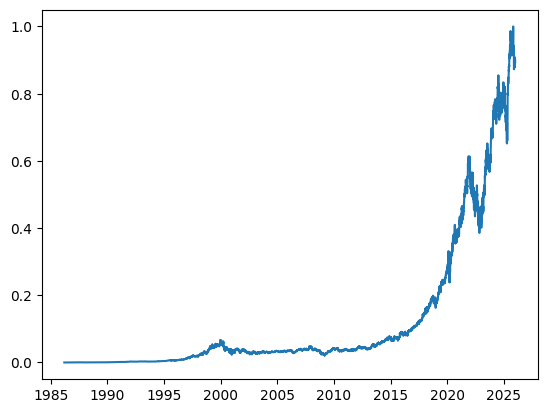

In [23]:
import matplotlib.pyplot as plt

plt.plot(df.index, df['Close'])

##  Visual Example

### Dataset
```
Mar 22
Mar 23
Mar 24
Mar 25
Mar 26
Mar 29 ← next trading day
```

### For `n = 3`

Input: `[Mar22, Mar23, Mar24]`  
Target: `Mar25`

### Next iteration : find the next days in 7 days range in Mar 25 -> 25,26,29,.....

Input: `[Mar23, Mar24, Mar25]`  
Target: `Mar26`

### Next iteration : find the next days in 7 days range in Mar 26 -> 26,29,.....

Input: `[Mar24, Mar25, Mar26]`  
Target: `Mar29`


In [24]:
import numpy as np

def df_to_windowed_df(dataframe, first_date_str, last_date_str, n=3):
  first_date = str_to_datetime(first_date_str)
  last_date  = str_to_datetime(last_date_str)

  target_date = first_date

  dates = []
  X, Y = [], []

  last_time = False
  while True:
    df_subset = dataframe.loc[:target_date].tail(n+1)

    if len(df_subset) != n+1:
      print(f'Error: Window of size {n} is too large for date {target_date}')
      return

    values = df_subset['Close'].to_numpy()
    x, y = values[:-1], values[-1]

    dates.append(target_date)
    X.append(x)
    Y.append(y)

    # stock markets are closed on sat,sun adn holidays so no data available for those days
    # so we seach for the days which  falls in the next 7 days of the target date to choose the next trading date
    next_week = dataframe.loc[target_date:target_date+datetime.timedelta(days=7)] 
    # chooses the next trading day top one is the previous trading day ,next one is the next trading day
    next_datetime_str = str(next_week.head(2).tail(1).index.values[0]) 
    next_date_str = next_datetime_str.split('T')[0]
    next_date = str_to_datetime(next_date_str)

    if last_time:
      break

    target_date = next_date

    if target_date == last_date:
      last_time = True

  ret_df = pd.DataFrame({})
  ret_df['Target Date'] = dates

  X = np.array(X)
  for i in range(0, n):
    X[:, i]
    ret_df[f'Target-{n-i}'] = X[:, i]

  ret_df['Target'] = Y

  return ret_df

# Start day second time around: '2021-03-25'
windowed_df = df_to_windowed_df(df,
                                '1986-05-01',
                                '2025-12-31',
                                n=20)
windowed_df

,Target Date,Target-20,Target-19,Target-18,Target-17,Target-16,Target-15,Target-14,Target-13,Target-12,...,Target-9,Target-8,Target-7,Target-6,Target-5,Target-4,Target-3,Target-2,Target-1,Target
0,1986-05-01,0.000007,0.000007,0.000005,0.000006,0.000008,0.000009,0.000011,0.000012,0.000012,...,0.000013,0.000013,0.000011,0.000011,0.000023,0.000030,0.000031,0.000027,0.000025,0.000023
1,1986-05-02,0.000007,0.000005,0.000006,0.000008,0.000009,0.000011,0.000012,0.000012,0.000016,...,0.000013,0.000011,0.000011,0.000023,0.000030,0.000031,0.000027,0.000025,0.000023,0.000023
2,1986-05-05,0.000005,0.000006,0.000008,0.000009,0.000011,0.000012,0.000012,0.000016,0.000017,...,0.000011,0.000011,0.000023,0.000030,0.000031,0.000027,0.000025,0.000023,0.000023,0.000022
3,1986-05-06,0.000006,0.000008,0.000009,0.000011,0.000012,0.000012,0.000016,0.000017,0.000013,...,0.000011,0.000023,0.000030,0.000031,0.000027,0.000025,0.000023,0.000023,0.000022,0.000023
4,1986-05-07,0.000008,0.000009,0.000011,0.000012,0.000012,0.000016,0.000017,0.000013,0.000013,...,0.000023,0.000030,0.000031,0.000027,0.000025,0.000023,0.000023,0.000022,0.000023,0.000023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9990,2025-12-24,0.881576,0.897307,0.909340,0.899599,0.905624,0.882944,0.888693,0.892981,0.907510,...,0.893554,0.884423,0.877565,0.880467,0.879968,0.894497,0.898083,0.896235,0.899802,0.901965
9991,2025-12-26,0.897307,0.909340,0.899599,0.905624,0.882944,0.888693,0.892981,0.907510,0.909358,...,0.884423,0.877565,0.880467,0.879968,0.894497,0.898083,0.896235,0.899802,0.901965,0.901392
9992,2025-12-29,0.909340,0.899599,0.905624,0.882944,0.888693,0.892981,0.907510,0.909358,0.884478,...,0.877565,0.880467,0.879968,0.894497,0.898083,0.896235,0.899802,0.901965,0.901392,0.900264
9993,2025-12-30,0.899599,0.905624,0.882944,0.888693,0.892981,0.907510,0.909358,0.884478,0.893554,...,0.880467,0.879968,0.894497,0.898083,0.896235,0.899802,0.901965,0.901392,0.900264,0.900966


In [25]:
def windowed_df_to_date_X_y(windowed_dataframe):
  df_as_np = windowed_dataframe.to_numpy()

  dates = df_as_np[:, 0]

  middle_matrix = df_as_np[:, 1:-1]
  X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))

  Y = df_as_np[:, -1]

  return dates, X.astype(np.float32), Y.astype(np.float32)

dates, X, y = windowed_df_to_date_X_y(windowed_df)

dates.shape, X.shape, y.shape

((9995,), (9995, 20, 1), (9995,))

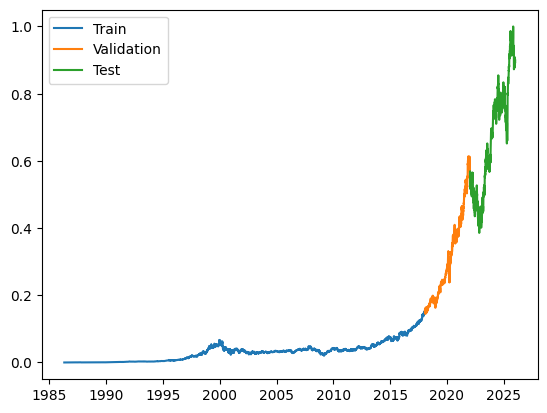

In [26]:
q_80 = int(len(dates) * .8)
q_90 = int(len(dates) * .9)
# 80% → Training
# 10% → Validation
# 10% → Testing

dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]

dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]

plt.plot(dates_train, y_train)
plt.plot(dates_val, y_val)
plt.plot(dates_test, y_test)

plt.legend(['Train', 'Validation', 'Test'])

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

model = Sequential([layers.Input((3, 1)),
                    layers.LSTM(64),
                    layers.Dense(32, activation='relu'),
                    layers.Dense(32, activation='relu'),
                    layers.Dense(1)])

model.compile(loss='mse',
              optimizer=Adam(learning_rate=0.001),
              metrics=['mean_absolute_error'])

model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 6.7616e-05 - mean_absolute_error: 0.0031 - val_loss: 0.0191 - val_mean_absolute_error: 0.1071
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 2.6560e-06 - mean_absolute_error: 0.0012 - val_loss: 0.0181 - val_mean_absolute_error: 0.1045
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 2.4739e-06 - mean_absolute_error: 0.0011 - val_loss: 0.0166 - val_mean_absolute_error: 0.0992
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 2.5430e-06 - mean_absolute_error: 0.0012 - val_loss: 0.0173 - val_mean_absolute_error: 0.1030
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 2.2359e-06 - mean_absolute_error: 0.0011 - val_loss: 0.0150 - val_mean_absolute_error: 0.0948
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.9316e-06 - mean_absolute_error: 9.8337e-04 - val_loss: 0.0144 - val_mean_absolute_error: 0.0930
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss

250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


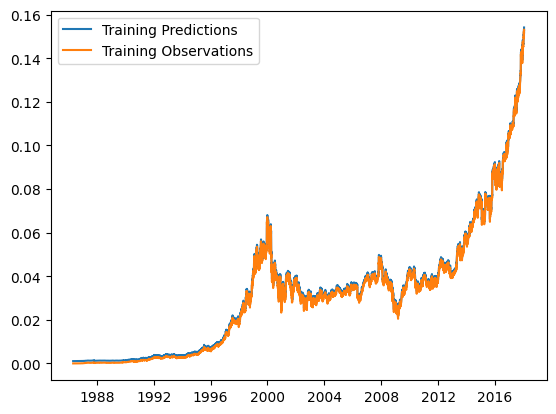

In [28]:
train_predictions = model.predict(X_train).flatten()

plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.legend(['Training Predictions', 'Training Observations'])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


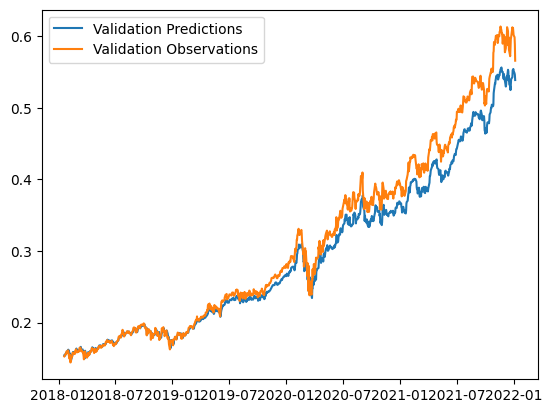

In [29]:
val_predictions = model.predict(X_val).flatten()

plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.legend(['Validation Predictions', 'Validation Observations'])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


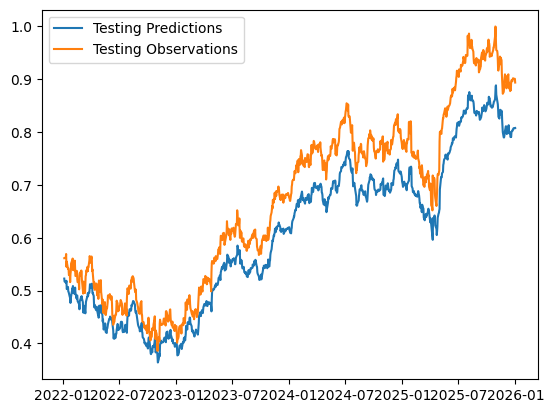

In [30]:
test_predictions = model.predict(X_test).flatten()

plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(['Testing Predictions', 'Testing Observations'])

In [ ]:
from copy import deepcopy

recursive_predictions = []
recursive_dates = np.concatenate([dates_val, dates_test])
last_window = deepcopy(X_train[-1])
count = 0
for target_date in recursive_dates:
    print(count)
    count += 1
    next_prediction = model.predict(np.array([last_window])).flatten()
    recursive_predictions.append(next_prediction)

    last_window = np.roll(last_window, -1)
    last_window[-1] = next_prediction
    
# [100,102,105]
# → predict 107
# → window becomes [102,105,107]

# → predict 109
# → window becomes [105,107,109]

0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
9
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
11
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
12
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
13
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
16
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
17
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
18
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
19
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
22
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
23
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
24
1/1 ━━━━━━━━━━━━━━━━━━━

In [ ]:
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.plot(recursive_dates, recursive_predictions)
plt.legend(['Training Predictions',
            'Training Observations',
            'Validation Predictions',
            'Validation Observations',
            'Testing Predictions',
            'Testing Observations',
            'Recursive Predictions'])

In [36]:
model.save("microsoft_stock_model.keras")

In [33]:
from tensorflow import keras

model = keras.models.load_model("stock_model.keras")

E:\3rd_sem_project\stock_price_predictor_models\v1\venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 11 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
